# Libraries

In [1]:
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install accelerate
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install diffusers
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install datasets
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install --upgrade pip
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install torch
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install -r requirements.txt
# !'/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python' -m pip install --upgrade cffi

In [2]:
# ! /users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/bin/python -m pip install --upgrade pip

In [3]:
import os
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch.optim import AdamW
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup
from datasets import load_dataset
from accelerate import Accelerator
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import random
import timeit

import json

from torchvision.datasets import ImageFolder


/users/PCS0229/imankhazrak/miniconda3/envs/ddpm_pytorch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Augmentation

In [4]:
# import os
# from torchvision import transforms
# from PIL import Image
# import shutil  # <--- Added this line

# # Define constants
# IMG_SIZE = 128
# NUM_AUGMENTED_IMAGES = 6  # Number of augmented images per image

# # Define paths
# class_name = "Cancer"
# class_dir = os.path.join(os.getcwd(), "Dataset/All", class_name)
# augmented_dir = os.path.join(os.getcwd(), "Dataset/All", f"{class_name}_augmented", class_name)
# if not os.path.exists(augmented_dir):
#     os.makedirs(augmented_dir)

# # Check the directory structure and contents
# print("Directory structure and contents:")
# for root, dirs, files in os.walk(class_dir):
#     level = root.replace(class_dir, '').count(os.sep)
#     indent = ' ' * 4 * (level)
#     print('{}{}/'.format(indent, os.path.basename(root)))
#     subindent = ' ' * 4 * (level + 1)
#     for f in files:
#         print('{}{}'.format(subindent, f))

# # Define data augmentation transformations
# augmentation_transforms = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomVerticalFlip(p=0.5),
# #     transforms.RandomRotation(degrees=45),
#     # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
#     # transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
#     transforms.ToTensor()
# ])

# to_pil = transforms.ToPILImage()

# # Load original images from the specified class directory
# original_images = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# # Copy original images to the augmented directory
# for img_path in original_images:  # <--- Added this block
#     shutil.copy(img_path, augmented_dir)

# # Function to save augmented images with labels in filenames
# def save_augmented_images(image_paths, transforms, num_images_per_image, save_dir):
#     count = 0
#     for img_path in image_paths:
#         img = Image.open(img_path)
#         for _ in range(num_images_per_image):
#             augmented_img = transforms(img)
#             save_path = os.path.join(save_dir, f"augmented_{class_name}_{count + 1}.png")
#             to_pil(augmented_img).save(save_path)
#             count += 1

# # Save augmented images
# save_augmented_images(original_images, augmentation_transforms, NUM_AUGMENTED_IMAGES, augmented_dir)

# print(f"Original and augmented images are saved to: {augmented_dir}")


# Hyperparameters

In [5]:
RANDOM_SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 16
LEARNING_RATE = 1e-4 # 1e-4
NUM_EPOCHS = 1024*3
NUM_GENERATE_IMAGES = 50
NUM_TIMESTEPS = 10000
MIXED_PRECISION = "fp16"
GRADIENT_ACCUMULATION_STEPS = 1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"


In [6]:
device

'cuda'

In [7]:
os.getcwd()

'/users/PCS0229/imankhazrak/Pink_Eye'

# Load dataset

Number of images in the dataset: 85


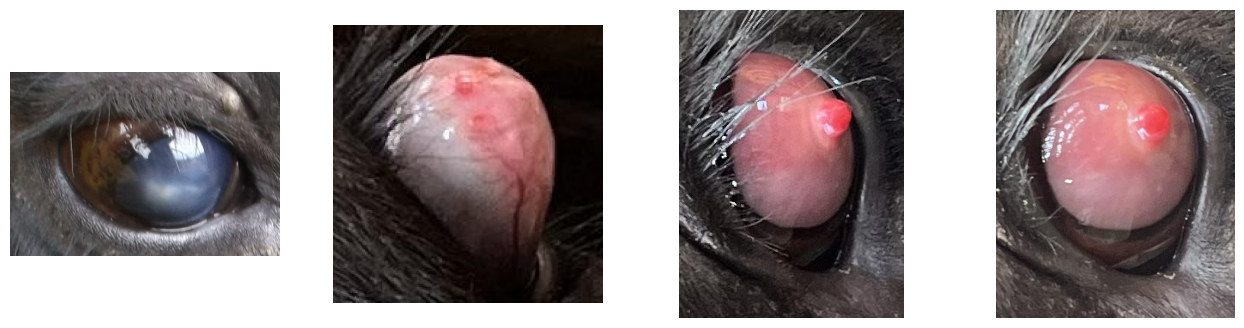

In [8]:
dataname = "pink_eye"#"Polyp"#"Cyct" "Without"#
# outputs/eye_crops_classification/healthy
dir_path = os.path.join(os.getcwd(), "outputs/eye_crops_classification/")
dataset = load_dataset(os.path.join(dir_path,dataname), split="train", trust_remote_code=True)
num_images = len(dataset)
print(f"Number of images in the dataset: {num_images}")

save_path = f"{dir_path}/BATCHSIZE{BATCH_SIZE}_TIMESTEPS{NUM_TIMESTEPS}_EPOCHS{NUM_EPOCHS}_checkpoint_{dataname}_num_images{num_images}.pth"

#showing images
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, image in enumerate(dataset[:4]["image"]):
    axs[i].imshow(image)
    axs[i].set_axis_off()
fig.show()

In [9]:

preprocess = transforms.Compose(
[
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}

dataset.set_transform(transform)


train_dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)


# U-Net

In [10]:
model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(256, 256, 512, 512, 1024, 1024), # (128, 128, 256, 256, 512, 512)
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D"
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    )
)
model = model.to(device)

In [11]:
sample_image = dataset[0]["images"].unsqueeze(0).to(device)
print("U-NET: Input shape", sample_image.shape)
print("U-NET: Output shape", model(sample_image, timestep=0).sample.shape)

U-NET: Input shape torch.Size([1, 3, 128, 128])
U-NET: Output shape torch.Size([1, 3, 128, 128])


In [12]:
noise_scheduler = DDPMScheduler(num_train_timesteps=NUM_TIMESTEPS)
noise = torch.randn(sample_image.shape).to(device)
timesteps = torch.LongTensor([50]).to(device)
noisy_image = noise_scheduler.add_noise(sample_image, noise, timesteps)
noise_pred = model(noisy_image, timesteps).sample
loss = F.mse_loss(noise_pred, noise)
print(loss)

tensor(1.1166, device='cuda:0', grad_fn=<MseLossBackward0>)


In [13]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(train_dataloader)*NUM_EPOCHS
)

accelerator = Accelerator(
    mixed_precision=MIXED_PRECISION,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS
)

model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(model, optimizer, train_dataloader, lr_scheduler)


In [12]:
# def sample_image_generation(model, noise_scheduler, NUM_GENERATE_IMAGES, RANDOM_SEED, NUM_TIMESTEPS):
#     pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler, verbose=0)
    
#     images = pipeline(
#         batch_size=NUM_GENERATE_IMAGES,
#         generator=torch.manual_seed(RANDOM_SEED),
#         num_inference_steps=NUM_TIMESTEPS
#     ).images
    
#     fig = plt.figure()
#     for i in range(1, NUM_GENERATE_IMAGES+1):
#         fig.add_subplot(10, 5, i)
#         plt.imshow(images[i-1])
#     plt.show()

# Train the model


In [14]:
# start = timeit.default_timer()

# training_metrics = {
#     'losses': [],
#     'mses': [],
#     'learning_rates': [],
# }

# for epoch in tqdm(range(NUM_EPOCHS), position=0, leave=True):
#     model.train()
#     train_running_loss = 0
#     mse_sum = 0  # Initialize sum of MSE for the epoch
#     for idx, batch in enumerate(tqdm(train_dataloader, position=0, leave=True)):
#         clean_images = batch["images"].to(device)
#         noise = torch.randn(clean_images.shape).to(device)
#         last_batch_size = len(clean_images)

#         timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (last_batch_size,)).to(device)
#         noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

#         with accelerator.accumulate(model):
#             noise_pred = model(noisy_images, timesteps, return_dict=False)[0]
#             loss = F.mse_loss(noise_pred, noise)
#             accelerator.backward(loss)

#             accelerator.clip_grad_norm_(model.parameters(), 1.0)
#             optimizer.step()
#             lr_scheduler.step()
#             optimizer.zero_grad()

#         train_running_loss += loss.item()
#         mse_sum += F.mse_loss(noise_pred, noise, reduction='sum').item()
#     train_loss = train_running_loss / (idx+1)
#     # mse_epoch = mse_sum / (idx + 1) * BATCH_SIZE  # Assuming each batch has BATCH_SIZE samples
#     mse_epoch = mse_sum / (len(train_dataloader.dataset))  # Adjust this based on how you calculate MSE

#     # Append the metrics for the current epoch to the dictionary
#     training_metrics['losses'].append(train_loss)
#     training_metrics['mses'].append(mse_epoch)
#     training_metrics['learning_rates'].append(lr_scheduler.get_last_lr()[0])
# #     print("-"*30)
# #     print(f"Train Loss EPOCH: {epoch+1}: {train_loss:.4f}")
# #     print(f"Train MSE EPOCH: {epoch+1}: {mse_epoch:.4f}")

#     train_learning_rate = lr_scheduler.get_last_lr()[0]
#     print("-"*30)
#     print(f"Train Loss EPOCH: {train_running_loss}: {idx+1}")
#     print(f"Train Loss EPOCH: {epoch+1}: {train_loss:.4f}")
#     print(f"Train Learning Rate EPOCH: {epoch+1}: {train_learning_rate}")
#     if epoch%40 == 0:
# #         sample_image_generation(model, noise_scheduler, NUM_GENERATE_IMAGES, RANDOM_SEED, NUM_TIMESTEPS)
# #         sample_image_generation3(model, noise_scheduler, NUM_GENERATE_IMAGES, RANDOM_SEED, NUM_TIMESTEPS, save_dir, dataname, epoch)
#         print("------iman----")

# stop = timeit.default_timer()
# print(f"Training Time: {stop-start:.2f}s")


# # dir_path = "/content/drive/MyDrive/4. BGSU/1.2 PhD_Courses/3. 7200_Machin Learning/Final_project/CS7200_SP2024_Project_G01/Notebooks/DDPM-Pytorch/save_model"

# # Check if the directory exists, if not, create it
# # if not os.path.exists(dir_path):
# #     os.makedirs(dir_path)

# # filename = f"{dir_path}/training_metrics_BATCHSIZE{BATCH_SIZE}_TIMESTEPS{NUM_TIMESTEPS}_EPOCHS{NUM_EPOCHS}_LEARNING_RATE{LEARNING_RATE}_{dataname}.json"

# # # Save the metrics to the file
# # with open(filename, 'w') as f:
# #     json.dump(training_metrics, f)

# # print(f"Metrics saved to {filename}")

  0%|          | 1/3072 [00:11<10:02:38, 11.77s/it]

------------------------------
Train Loss EPOCH: 6.158898949623108: 6
Train Loss EPOCH: 1: 1.0265
Train Learning Rate EPOCH: 1: 1.2000000000000002e-06
------iman----


  0%|          | 2/3072 [00:15<5:59:54,  7.03s/it] 

------------------------------
Train Loss EPOCH: 5.8288461565971375: 6
Train Loss EPOCH: 2: 0.9715
Train Learning Rate EPOCH: 2: 2.4000000000000003e-06


  0%|          | 3/3072 [00:19<4:42:22,  5.52s/it]

...

------------------------------
Train Loss EPOCH: 0.02537802876031492: 6
Train Loss EPOCH: 3070: 0.0042
Train Learning Rate EPOCH: 3070: 1.5039664467142444e-10


100%|█████████▉| 3071/3072 [3:10:43<00:03,  3.72s/it]

------------------------------
Train Loss EPOCH: 0.015735474051325582: 6
Train Loss EPOCH: 3071: 0.0026
Train Learning Rate EPOCH: 3071: 4.9109125044299875e-11


100%|██████████| 3072/3072 [3:10:47<00:00,  3.73s/it]

------------------------------
Train Loss EPOCH: 0.005107797929667868: 6
Train Loss EPOCH: 3072: 0.0009
Train Learning Rate EPOCH: 3072: 3.0693207864196384e-12
Training Time: 11447.24s


# Saving checkpoints


In [17]:
# checkpoint = {
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "scheduler_state_dict": lr_scheduler.state_dict(),
# }

# # Save checkpoint
# torch.save(checkpoint, save_path)


# Load the checkpoint

In [14]:
checkpoint = torch.load(save_path)

# Load states into the model, optimizer, and scheduler
model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
lr_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])


# Generate Images

In [15]:
def sample_image_generation2(model, noise_scheduler, NUM_GENERATE_IMAGES, RANDOM_SEED, NUM_TIMESTEPS, save_dir, dataname):
    pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

    images = pipeline(
        batch_size=NUM_GENERATE_IMAGES,
        generator=torch.manual_seed(RANDOM_SEED),
        num_inference_steps=NUM_TIMESTEPS
    ).images

    for i, image in enumerate(images):
        if not os.path.exists(save_dir):
            # If the directory does not exist, create it
            os.makedirs(save_dir)
        save_path = os.path.join(save_dir, f"generated_image_{dataname}_{i+1}.png")
        if not isinstance(image, Image.Image):
            # Convert tensor image to PIL Image only if necessary
            pil_image = transforms.ToPILImage()(image)
        else:
            # If it's already a PIL image, no need to convert
            pil_image = image
        pil_image.save(save_path)

    fig = plt.figure()
    # for i in range(1, NUM_GENERATE_IMAGES+1):
    for i in range(1, 10):
        fig.add_subplot(3, 3, i)
        plt.imshow(images[i-1])
    plt.show()

In [ ]:
NUM_GENERATE_IMAGES = 100
RANDOM_SEED = 42
save_dir = f"{dir_path}/save_images_BATCHSIZE{BATCH_SIZE}_TIMESTEPS{NUM_TIMESTEPS}_EPOCHS{NUM_EPOCHS}_{dataname}_num_images{num_images}_{RANDOM_SEED}"
sample_image_generation2(model, noise_scheduler, NUM_GENERATE_IMAGES, RANDOM_SEED, NUM_TIMESTEPS, save_dir, dataname)

 59%|█████▉    | 5895/10000 [1:53:04<1:18:42,  1.15s/it]